In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

file_name = "3) Sentiment dataset.csv"
df = pd.read_csv(file_name)
df.columns = df.columns.str.strip()

df['Cleaned_Text'] = df['Text'].apply(clean_text)
df['Sentiment'] = df['Sentiment'].str.strip()

df = df[df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])].copy()
df['Label'] = df['Sentiment'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})

print("Multi-Class Distribution for Neural Network:")
print(df['Sentiment'].value_counts())

Multi-Class Distribution for Neural Network:
Sentiment
Positive    45
Neutral     18
Negative     4
Name: count, dtype: int64


In [ ]:
X = df['Cleaned_Text']
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

max_features = 2000
vectorizer = TfidfVectorizer(max_words=max_features, stop_words='english') if hasattr(TfidfVectorizer(), 'max_words') else TfidfVectorizer(max_features=max_features, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

print(f"Neural Network Input Train Shape: {X_train_tfidf.shape}")
print(f"Neural Network Input Test Shape: {X_test_tfidf.shape}")

Neural Network Input Train Shape: (53, 206)
Neural Network Input Test Shape: (14, 206)


In [15]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,339 (56.01 KB)

 Trainable params: 14,339 (56.01 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Programmatic Class Weights Calculated:")
print(class_weight_dict)

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = model.fit(
    X_train_tfidf, y_train,
    epochs=35,
    batch_size=8,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Programmatic Class Weights Calculated:
{0: np.float64(5.888888888888889), 1: np.float64(1.2619047619047619), 2: np.float64(0.49074074074074076)}
Epoch 1/35
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.4222 - loss: 1.1583 - val_accuracy: 0.6250 - val_loss: 1.0741
Epoch 2/35
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.4444 - loss: 1.1484 - val_accuracy: 0.6250 - val_loss: 1.0703
Epoch 3/35
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6000 - loss: 1.1321 - val_accuracy: 0.6250 - val_loss: 1.0645
Epoch 4/35
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7111 - loss: 1.1172 - val_accuracy: 0.6250 - val_loss: 1.0620
Epoch 5/35
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8444 - loss: 1.0874 - val_accuracy: 0.6250 - val_loss: 1.0576
Epoch 6/35
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7778 - loss: 1.1070 - val_accuracy: 0.6250 - val_loss: 1.0496
Epoch 7/35
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 1.0736 - val_accuracy: 0.625

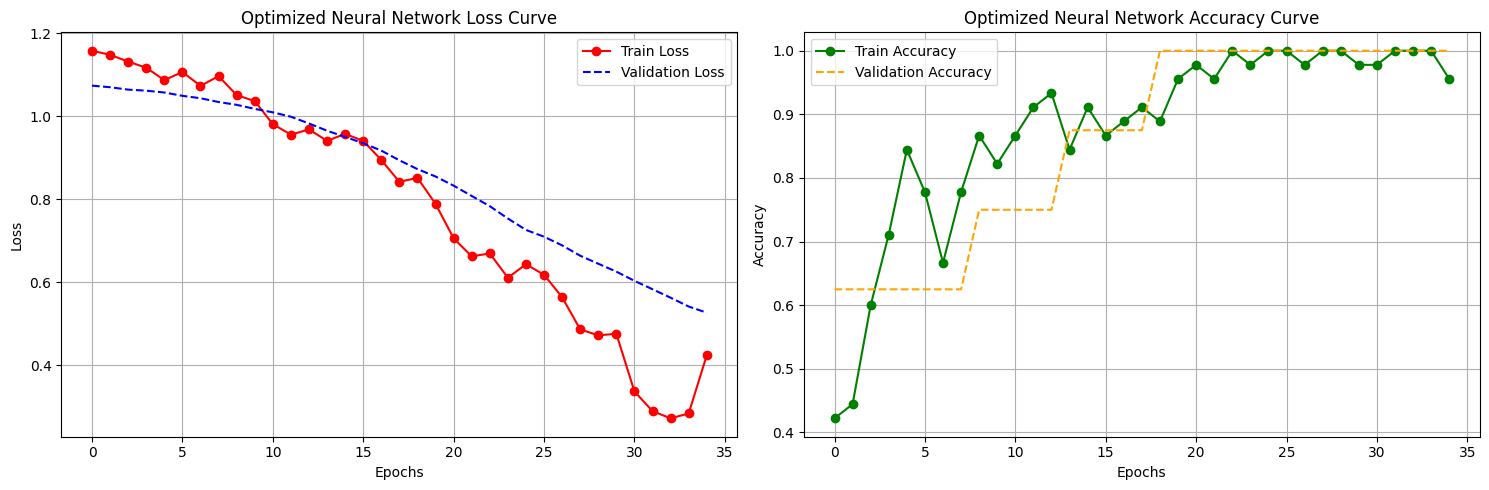

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step

Final Programmatic Neural Network Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.25      0.33         4
           2       0.67      0.89      0.76         9

    accuracy                           0.64        14
   macro avg       0.39      0.38      0.37        14
weighted avg       0.57      0.64      0.59        14



In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history['loss'], label='Train Loss', color='red', marker='o')
ax[0].plot(history.history['val_loss'], label='Validation Loss', color='blue', linestyle='--')
ax[0].set_title('Optimized Neural Network Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history.history['accuracy'], label='Train Accuracy', color='green', marker='o')
ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
ax[1].set_title('Optimized Neural Network Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig('neural_network_curves.png')
plt.show()

preds = np.argmax(model.predict(X_test_tfidf), axis=-1)
print("\nFinal Programmatic Neural Network Classification Report:\n")
print(classification_report(y_test, preds, zero_division=0))